# Examen Jeremy — Prédiction du prix du Bitcoin avec Machine Learning

## Objectif :
Construire 2 modèles de régression (Linear Regression et Lasso) pour prédire le prix de clôture du Bitcoin du lendemain à partir des données historiques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("data/bitcoin_usd_2020_2025_clean.csv")

In [3]:
df.head()
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2191 non-null   object 
 1   Open    2191 non-null   float64
 2   High    2191 non-null   float64
 3   Low     2191 non-null   float64
 4   Close   2191 non-null   float64
 5   Volume  2191 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 102.8+ KB


Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

## Observation initiale

Le dataset contient des données historiques du Bitcoin avec les colonnes Date, Open, High, Low, Close et Volume.

La majorité des colonnes sont numériques, tandis que Date est actuellement en format texte.

Aucune valeur manquante n’est présente à cette étape initiale.

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df["Target"] = df["Close"].shift(-1)

df = df.dropna()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2190 entries, 0 to 2189
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2190 non-null   datetime64[ns]
 1   Open    2190 non-null   float64       
 2   High    2190 non-null   float64       
 3   Low     2190 non-null   float64       
 4   Close   2190 non-null   float64       
 5   Volume  2190 non-null   int64         
 6   Target  2190 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 136.9 KB


## Nettoyage et préparation

La colonne Date a été convertie en format datetime afin de respecter l’ordre chronologique des observations.

Une nouvelle colonne Target a été créée en décalant la colonne Close d’une journée vers le haut.

Cela permet de faire prédire au modèle le prix de clôture du lendemain.

La dernière ligne a été supprimée, car aucune valeur future n’était disponible pour cette observation.

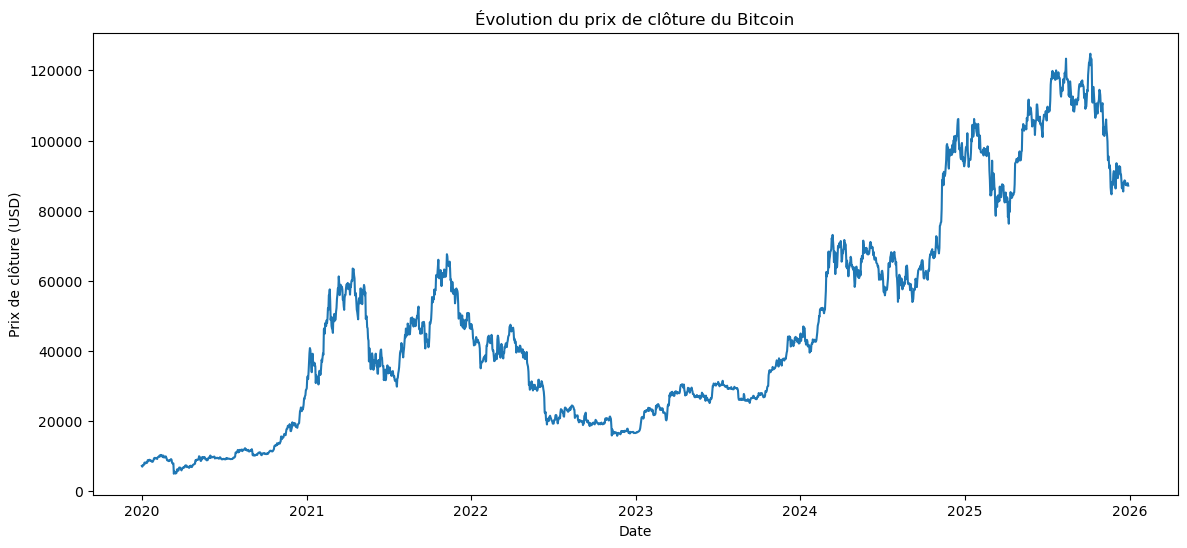

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"])

plt.title("Évolution du prix de clôture du Bitcoin")
plt.xlabel("Date")
plt.ylabel("Prix de clôture (USD)")

plt.show()

## Interprétation du graphique

On observe une forte évolution du prix du Bitcoin au fil du temps.

Le marché présente une tendance générale haussière, mais avec plusieurs fluctuations importantes.

Cela confirme que les cryptomonnaies sont des actifs volatils.

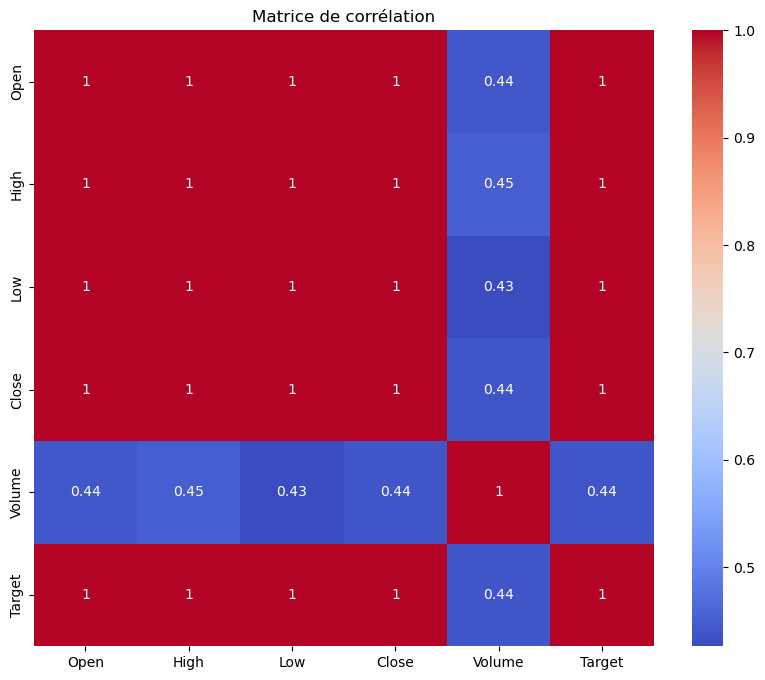

In [7]:
plt.figure(figsize=(10, 8))

corr = df[["Open", "High", "Low", "Close", "Volume", "Target"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matrice de corrélation")

plt.show()

## Interprétation de la matrice de corrélation

Les variables Open, High, Low et Close montrent une très forte corrélation avec Target.

Le volume semble moins fortement corrélé.

Cela suggère que les prix historiques sont de meilleurs indicateurs pour la prédiction que le volume échangé.

In [8]:
features = ["Open", "High", "Low", "Close", "Volume"]

X = df[features]
y = df["Target"]

## Création des variables explicatives et de la cible

Les variables explicatives X contiennent les informations de la journée actuelle :

- Open
- High
- Low
- Close
- Volume

La variable cible y correspond au prix de clôture du lendemain (Target).

La colonne Target n’est pas incluse dans X afin d’éviter une fuite de données.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [10]:
print("Taille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)
print("Taille y_train :", y_train.shape)
print("Taille y_test :", y_test.shape)

Taille X_train : (1752, 5)
Taille X_test : (438, 5)
Taille y_train : (1752,)
Taille y_test : (438,)


## Séparation des données

Les données ont été séparées en ensemble d’entraînement et ensemble de test.

80 % des données servent à entraîner les modèles.

20 % servent à évaluer les performances sur des données jamais vues.

Le paramètre shuffle=False a été utilisé afin de conserver l’ordre chronologique des observations.

In [11]:
linear_model = make_pipeline(
    RobustScaler(),
    LinearRegression()
)

linear_model.fit(X_train, y_train)

,steps,"[('robustscaler', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,fit_intercept,True
,copy_X,True


In [13]:
lasso_model = make_pipeline(
    RobustScaler(),
    Lasso(alpha=0.01, max_iter=50000)
)

lasso_model.fit(X_train, y_train)

,steps,"[('robustscaler', ...), ('lasso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,alpha,0.01
,fit_intercept,True


In [14]:
y_pred_linear = linear_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

score_linear = r2_score(y_test, y_pred_linear)
score_lasso = r2_score(y_test, y_pred_lasso)

print("Score R² Linear Regression :", score_linear)
print("Score R² Lasso :", score_lasso)

Score R² Linear Regression : 0.9711615541617198
Score R² Lasso : 0.9711700685817569


## Évaluation des modèles

Le score R² permet de mesurer la qualité des prédictions.

Un score proche de 1 signifie que le modèle explique très bien les variations de la variable cible.

Le meilleur modèle sera celui ayant le score R² le plus élevé.

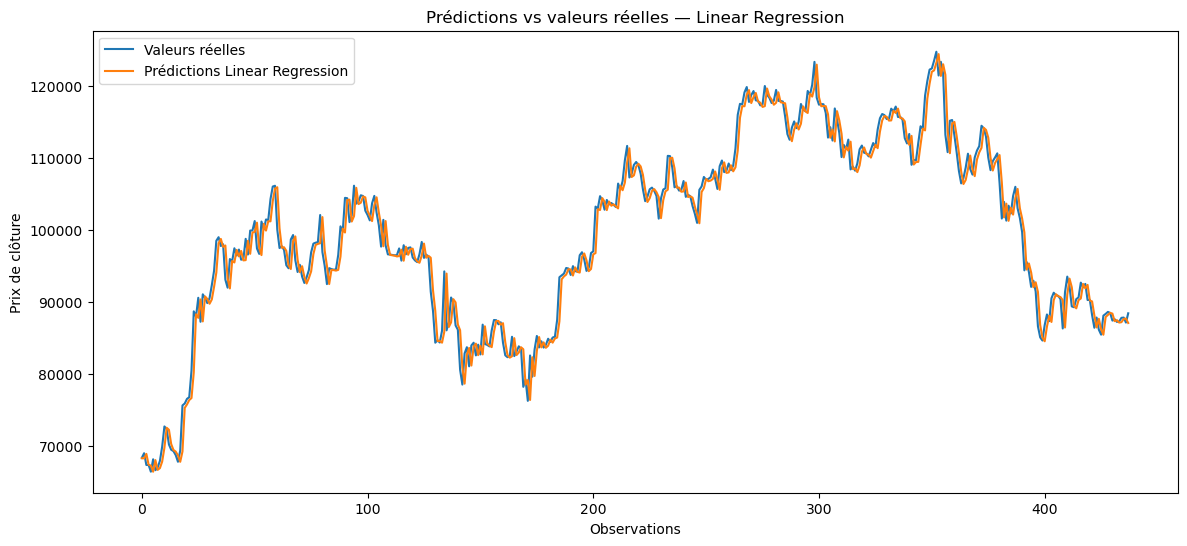

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(y_test.values, label="Valeurs réelles")
plt.plot(y_pred_linear, label="Prédictions Linear Regression")

plt.title("Prédictions vs valeurs réelles — Linear Regression")
plt.xlabel("Observations")
plt.ylabel("Prix de clôture")

plt.legend()
plt.show()

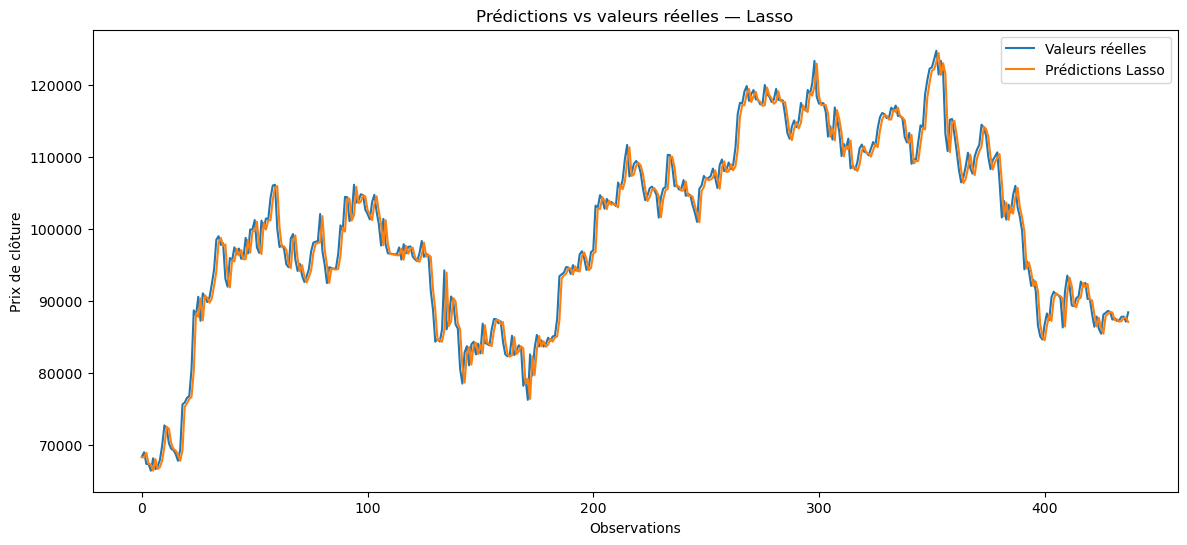

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(y_test.values, label="Valeurs réelles")
plt.plot(y_pred_lasso, label="Prédictions Lasso")

plt.title("Prédictions vs valeurs réelles — Lasso")
plt.xlabel("Observations")
plt.ylabel("Prix de clôture")

plt.legend()
plt.show()

## Interprétation des prédictions

Les 2 modèles suivent très bien les valeurs réelles observées.

Les courbes sont presque superposées, ce qui confirme les scores R² élevés obtenus.

Le modèle Lasso semble légèrement meilleur selon le score obtenu.

In [17]:
if score_linear > score_lasso:
    best_model = linear_model
    best_model_name = "Linear Regression"
else:
    best_model = lasso_model
    best_model_name = "Lasso"

print("Meilleur modèle :", best_model_name)

Meilleur modèle : Lasso


In [18]:
prediction = best_model.predict(X_test.iloc[[0]])

print("Meilleur modèle :", best_model_name)
print("Prédiction :", prediction[0])
print("Vraie valeur :", y_test.iloc[0])

Meilleur modèle : Lasso
Prédiction : 68300.99879490258
Vraie valeur : 68362.734375


## Prédiction avec le meilleur modèle

Une prédiction a été effectuée sur une observation réelle provenant de l’ensemble de test.

La valeur prédite peut être comparée à la vraie valeur afin d’évaluer concrètement la précision du modèle.

Comme les scores R² sont très élevés, la prédiction devrait être relativement proche de la réalité.

# Questions d’interprétation

## Quel modèle obtient le meilleur score R² ?

Le modèle Lasso obtient le meilleur score R², bien que la différence avec Linear Regression soit très faible.

## Que signifie un score R² proche de 1 ?

Un score R² proche de 1 signifie que le modèle explique très bien les variations de la variable cible et produit des prédictions très précises.

## Pourquoi la colonne Target ne doit-elle pas être incluse dans X ?

Parce que Target contient directement la réponse que le modèle doit prédire.

Si elle est incluse, le modèle triche en ayant accès à la réponse pendant l’entraînement.

## Pourquoi utilise-t-on shuffle=False ?

Parce que les données sont temporelles.

Il faut conserver l’ordre chronologique afin que le modèle apprenne sur le passé et soit testé sur le futur.

## Le modèle peut-il prédire parfaitement le futur prix d’une cryptomonnaie ?

Non. Même avec un bon score, les cryptomonnaies restent très volatiles et influencées par des événements imprévisibles comme l’actualité économique, politique ou technologique.